# Exploring Planck+ACT CMB Power Spectra (Combined Cut Version)

This notebook explores the combined Planck+ACT CMB power spectra data products, following the PlanckActCut combination strategy:
- **TT**: Planck ℓ<1000, ACT ℓ≥600
- **TE**: Planck ℓ<600, ACT ℓ≥600
- **EE**: Planck ℓ<600, ACT ℓ≥600

**Data sources:**
1. ACT DR6 CMB-only: `/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits`
2. Planck plik_lite: `/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

%config InlineBackend.figure_format='retina'

# ell cuts for Planck+ACT combination (following PlanckActCut.yaml)
ELL_CUTS = {
    'TT': {'planck_max': 1000, 'act_min': 600},
    'TE': {'planck_max': 600, 'act_min': 600},
    'EE': {'planck_max': 600, 'act_min': 600},
}
print("ell cuts for Planck+ACT combination:")
for spec, cuts in ELL_CUTS.items():
    print(f"  {spec}: Planck ℓ<{cuts['planck_max']}, ACT ℓ≥{cuts['act_min']}")

ell cuts for Planck+ACT combination:
  TT: Planck ℓ<1000, ACT ℓ≥600
  TE: Planck ℓ<600, ACT ℓ≥600
  EE: Planck ℓ<600, ACT ℓ≥600


## 1. Load the Data Files

In [2]:
# Load ACT DR6 SACC file
act_sacc_file = '/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits'
act_s = sacc.Sacc.load_fits(act_sacc_file)
print(f"ACT SACC file loaded: {len(act_s.data)} data points")

# Load Planck plik_lite data
planck_dir = '/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/'
planck_data = np.loadtxt(planck_dir + 'cl_cmb_plik_v22.dat')
print(f"Planck plik_lite loaded: {len(planck_data)} data points")

# Planck bin structure: nbintt=215, nbinte=199, nbinee=199
PLANCK_NBINS = {'TT': 215, 'TE': 199, 'EE': 199}

ACT SACC file loaded: 127 data points
Planck plik_lite loaded: 613 data points


## 2. Extract Planck Spectra

Planck plik_lite stores bandpowers as $D_\ell = \ell(\ell+1)C_\ell/(2\pi)$ in units of $10^3 \mu K^2$.

In [3]:
def extract_planck_spectra(data, nbins, planck_dir):
    """Extract Planck TT, TE, EE spectra from plik_lite data file.
    
    The plik_lite data file stores: ell, Cl_value, Cl_error
    We convert to Dl = Cl * ell*(ell+1)/(2*pi) in μK^2.
    
    Based on cobaya's PlanckPlikLite implementation.
    
    IMPORTANT: Each spectrum (TT, TE, EE) uses the same bin indices 0:nbin.
    The ell ranges are:
    - TT: blmin/blmax[0:215], ℓ = 32–2492
    - TE: blmin/blmax[0:199], ℓ = 32–1988
    - EE: blmin/blmax[0:199], ℓ = 32–1988
    """
    # Read bin edge files to get proper ell values
    bin_lmin_offset = 30  # from plik_lite_v22.dataset
    blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
    blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset
    
    spectra = {}
    data_idx = 0  # Index into the data file (sequential)
    
    for name in ['TT', 'TE', 'EE']:
        n = nbins[name]
        chunk = data[data_idx:data_idx + n]
        
        # FIXED: Each spectrum uses bin indices 0:nbin (not sequential slices)
        ell_avg = (blmin[0:n] + blmax[0:n]) // 2
        
        # Convert from Cl to Dl: Dl = Cl * ell*(ell+1)/(2*pi)
        sc = ell_avg * (ell_avg + 1) / (2 * np.pi)
        
        spectra[name] = {
            'ells': ell_avg.astype(float),
            'dls': chunk[:, 1] * sc,  # Convert Cl to Dl (in μK^2)
            'errs': chunk[:, 2] * sc,  # Same conversion for errors
        }
        data_idx += n  # Move forward in data file
        
        ell_range = f"[{ell_avg[0]}, {ell_avg[-1]}]"
        print(f"Planck {name}: {n} bins, ℓ={ell_range}")
    
    return spectra

planck_spectra = extract_planck_spectra(planck_data, PLANCK_NBINS, planck_dir)

Planck TT: 215 bins, ℓ=[32, 2492]
Planck TE: 199 bins, ℓ=[32, 1988]
Planck EE: 199 bins, ℓ=[32, 1988]


## 3. Extract ACT DR6 Spectra

ACT DR6 CMB-only stores bandpowers as $D_\ell$ in $\mu K^2$.

In [4]:
def extract_act_spectrum(s, data_type):
    """Extract ell, Dl, and errors for a SACC data type."""
    indices = s.indices(data_type)
    if len(indices) == 0:
        return None, None, None
    
    ells = np.array([s.data[i].get_tag('ell') for i in indices])
    dls = np.array([s.data[i].value for i in indices])
    
    if s.covariance is not None:
        errs = np.sqrt(np.diag(s.covariance.dense[np.ix_(indices, indices)]))
    else:
        errs = None
    
    sort_idx = np.argsort(ells)
    return ells[sort_idx], dls[sort_idx], errs[sort_idx] if errs is not None else None


# SACC type mappings for CMB spectra
ACT_TYPE_MAP = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}

act_spectra = {}
for name, sacc_type in ACT_TYPE_MAP.items():
    if sacc_type in act_s.get_data_types():
        ells, dls, errs = extract_act_spectrum(act_s, sacc_type)
        if ells is not None:
            act_spectra[name] = {'ells': ells, 'dls': dls, 'errs': errs}
            print(f"ACT {name}: {len(ells)} bins, ℓ=[{ells.min():.0f}, {ells.max():.0f}]")

ACT TT: 45 bins, ℓ=[598, 6124]
ACT TE: 40 bins, ℓ=[598, 4124]
ACT EE: 42 bins, ℓ=[498, 4124]


## 4. Load Theory Power Spectra

Load fiducial theory Cℓ from orphics and convert to Dℓ = ℓ(ℓ+1)Cℓ/(2π).

In [5]:
# Load theory power spectra from orphics
from orphics import cosmology

theory = cosmology.default_theory()

# Get theory ells up to 7000
ells_theory = np.arange(2, 7001)

# Get lensed Cl in uK^2 and convert to Dl
theory_spectra = {}
for name in ['TT', 'TE', 'EE']:
    cl = theory.lCl(name, ells_theory)
    dl = ells_theory * (ells_theory + 1) / (2 * np.pi) * cl
    theory_spectra[name] = {'ells': ells_theory, 'dls': dl}
    print(f"Theory {name}: ell=[{ells_theory.min()}, {ells_theory.max()}], Dl range=[{dl.min():.1f}, {dl.max():.1f}] uK^2")


Theory TT: ell=[2, 7000], Dl range=[0.2, 5733.3] uK^2
Theory TE: ell=[2, 7000], Dl range=[-134.3, 120.2] uK^2
Theory EE: ell=[2, 7000], Dl range=[0.0, 42.4] uK^2


## 5. Apply ell Cuts for Planck+ACT Combination

In [6]:
def apply_ell_cuts(planck_spec, act_spec, ell_cuts):
    """Apply ell cuts to create combined Planck+ACT dataset.
    
    Returns dictionaries with cut data for each experiment.
    """
    planck_cut = {}
    act_cut = {}
    
    for name in ['TT', 'TE', 'EE']:
        cuts = ell_cuts[name]
        
        # Planck: keep ℓ < planck_max
        if name in planck_spec:
            mask = planck_spec[name]['ells'] < cuts['planck_max']
            planck_cut[name] = {
                'ells': planck_spec[name]['ells'][mask],
                'dls': planck_spec[name]['dls'][mask],
                'errs': planck_spec[name]['errs'][mask],
            }
            print(f"Planck {name}: {mask.sum()} bins after cut (ℓ<{cuts['planck_max']})")
        
        # ACT: keep ℓ >= act_min
        if name in act_spec:
            mask = act_spec[name]['ells'] >= cuts['act_min']
            act_cut[name] = {
                'ells': act_spec[name]['ells'][mask],
                'dls': act_spec[name]['dls'][mask],
                'errs': act_spec[name]['errs'][mask],
            }
            print(f"ACT {name}: {mask.sum()} bins after cut (ℓ≥{cuts['act_min']})")
    
    return planck_cut, act_cut

planck_cut, act_cut = apply_ell_cuts(planck_spectra, act_spectra, ELL_CUTS)

Planck TT: 114 bins after cut (ℓ<1000)
ACT TT: 44 bins after cut (ℓ≥600)
Planck TE: 70 bins after cut (ℓ<600)
ACT TE: 39 bins after cut (ℓ≥600)
Planck EE: 70 bins after cut (ℓ<600)
ACT EE: 39 bins after cut (ℓ≥600)


## 5b. Theory Binning

To compare theory with data, we must bin the theory Cℓ using bandpower windows:
- **ACT**: Uses SACC bandpower windows (`window.weight @ theory`)
- **Planck**: Uses `bweight.dat` binning weights

The binning operation: `Cℓ_binned = W @ Cℓ_theory` where W is the window/binning matrix.

In [7]:
# Build binning matrices and bin theory spectra

def build_planck_binning_matrix(planck_dir, nbins_dict, bin_lmin_offset=30, lmax=2508):
    """Build Planck binning matrices from bweight.dat, blmin.dat, blmax.dat.
    
    Following cobaya PlanckPlikLite implementation.
    
    IMPORTANT: Each spectrum (TT, TE, EE) uses bin indices 0:nbin, NOT sequential slices.
    - TT: blmin/blmax[0:215], ell = 32-2492
    - TE: blmin/blmax[0:199], ell = 32-1988
    - EE: blmin/blmax[0:199], ell = 32-1988
    
    The weights are for Cl binning (bweight.dat). We pad them so weights[ell] works directly.
    """
    # Load raw data
    weights_raw = np.loadtxt(planck_dir + 'bweight.dat')
    blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int)  # raw indices (not ell)
    blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int)
    
    print(f"DEBUG: bweight has {len(weights_raw)} entries")
    print(f"DEBUG: blmin has {len(blmin)} entries, range: [{blmin.min()}, {blmax.max()}]")
    
    # Pad weights so weights[ell] works directly (ell = raw_index + bin_lmin_offset)
    # weights_raw[0] corresponds to ell=30, weights_raw[1] to ell=31, etc.
    weights = np.hstack((np.zeros(bin_lmin_offset), weights_raw))
    
    print(f"DEBUG: padded weights length: {len(weights)} (so weights[ell] works for ell >= {bin_lmin_offset})")
    
    n_theory = lmax + 1  # theory ells from 0 to lmax
    binning_matrices = {}
    
    for name in ['TT', 'TE', 'EE']:
        nbins = nbins_dict[name]
        binning_matrix = np.zeros((nbins, n_theory))
        
        # FIXED: Each spectrum uses bin indices 0:nbin (not sequential slices)
        for i in range(nbins):
            lmin_bin = blmin[i] + bin_lmin_offset  # actual ell min for this bin
            lmax_bin = blmax[i] + bin_lmin_offset  # actual ell max for this bin
            
            # Fill binning matrix with Cl weights
            for ell in range(lmin_bin, min(lmax_bin + 1, lmax + 1)):
                if ell < len(weights):
                    binning_matrix[i, ell] = weights[ell]
        
        # Debug: check the binning matrix
        row_sums = binning_matrix.sum(axis=1)
        nonzero_rows = (row_sums > 0).sum()
        ell_range_first = blmin[0] + bin_lmin_offset
        ell_range_last = blmax[nbins-1] + bin_lmin_offset
        
        print(f"Planck {name}: {nbins} bins, ell range [{ell_range_first}, {ell_range_last}], "
              f"nonzero rows: {nonzero_rows}/{nbins}, row_sums range: [{row_sums.min():.4f}, {row_sums.max():.4f}]")
        
        binning_matrices[name] = binning_matrix
    
    return binning_matrices

# Build Planck binning matrices
planck_binning = build_planck_binning_matrix(planck_dir, PLANCK_NBINS)

# Bin theory spectra for Planck
# IMPORTANT: bweight is designed for Cl, not Dl!
# Process: Dl -> Cl -> bin -> Dl
planck_theory_binned = {}
lmax_planck = 2508

for name in ['TT', 'TE', 'EE']:
    th = theory_spectra[name]
    
    # Create Cl array (convert from Dl: Cl = Dl * 2*pi / (ell*(ell+1)))
    cl_full = np.zeros(lmax_planck + 1)
    valid_mask = (th['ells'] >= 2) & (th['ells'] <= lmax_planck)
    valid_ells = th['ells'][valid_mask].astype(int)
    valid_dls = th['dls'][valid_mask]
    
    # Convert Dl to Cl
    ell_factor = valid_ells * (valid_ells + 1) / (2 * np.pi)
    cl_full[valid_ells] = valid_dls / ell_factor
    
    # Bin Cl using Planck weights
    cl_binned = planck_binning[name] @ cl_full
    
    # Convert binned Cl back to Dl using the correct ells for this spectrum
    ell_avg = planck_spectra[name]['ells']
    dl_factor = ell_avg * (ell_avg + 1) / (2 * np.pi)
    dl_binned = cl_binned * dl_factor
    
    planck_theory_binned[name] = {'ells': ell_avg, 'dls': dl_binned}
    print(f"Planck {name} theory: cl_binned range [{cl_binned.min():.6f}, {cl_binned.max():.6f}], "
          f"Dl range: [{dl_binned.min():.1f}, {dl_binned.max():.1f}]")

DEBUG: bweight has 7437 entries
DEBUG: blmin has 645 entries, range: [0, 7436]
DEBUG: padded weights length: 7467 (so weights[ell] works for ell >= 30)
Planck TT: 215 bins, ell range [30, 2508], nonzero rows: 215/215, row_sums range: [1.0000, 1.0000]
Planck TE: 199 bins, ell range [30, 1996], nonzero rows: 199/199, row_sums range: [1.0000, 1.0000]
Planck EE: 199 bins, ell range [30, 1996], nonzero rows: 199/199, row_sums range: [1.0000, 1.0000]
Planck TT theory: cl_binned range [0.000081, 6.536532], Dl range: [80.4, 5730.3]
Planck TE theory: cl_binned range [-0.015477, 0.011614], Dl range: [-133.9, 120.0]
Planck EE theory: cl_binned range [0.000015, 0.000941], Dl range: [0.0, 42.3]


In [8]:
# Bin theory for ACT using SACC bandpower windows
# Following act_dr6_cmbonly.py chi_square() pattern

def bin_theory_act(sacc_obj, theory_spectra, sacc_type_map):
    """Bin theory spectra using ACT SACC bandpower windows."""
    act_theory_binned = {}
    
    for name, sacc_type in sacc_type_map.items():
        if sacc_type not in sacc_obj.get_data_types():
            continue
            
        indices = sacc_obj.indices(sacc_type)
        ells_data = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
        
        # Get bandpower windows for these indices
        windows = sacc_obj.get_bandpower_windows(indices)
        
        # windows.weight has shape (n_theory_ells, n_bins)
        # windows.values has the theory ell values
        win_matrix = windows.weight.T  # (n_bins, n_theory_ells)
        theory_ells = windows.values.astype(int)
        
        # Get theory Dl at window ells
        th = theory_spectra[name]
        # Interpolate theory to window ells if needed
        theory_dl_at_window = np.interp(theory_ells, th['ells'], th['dls'])
        
        # Bin: Dl_binned = window @ Dl_theory
        dl_binned = win_matrix @ theory_dl_at_window
        
        act_theory_binned[name] = {
            'ells': ells_data,
            'dls': dl_binned,
            'window_matrix': win_matrix,
            'window_ells': theory_ells
        }
        print(f"ACT {name} theory binned: {len(dl_binned)} bins, window shape: {win_matrix.shape}")
    
    return act_theory_binned

act_theory_binned = bin_theory_act(act_s, theory_spectra, ACT_TYPE_MAP)

ACT TT theory binned: 45 bins, window shape: (45, 6501)
ACT TE theory binned: 40 bins, window shape: (40, 4201)
ACT EE theory binned: 42 bins, window shape: (42, 4201)


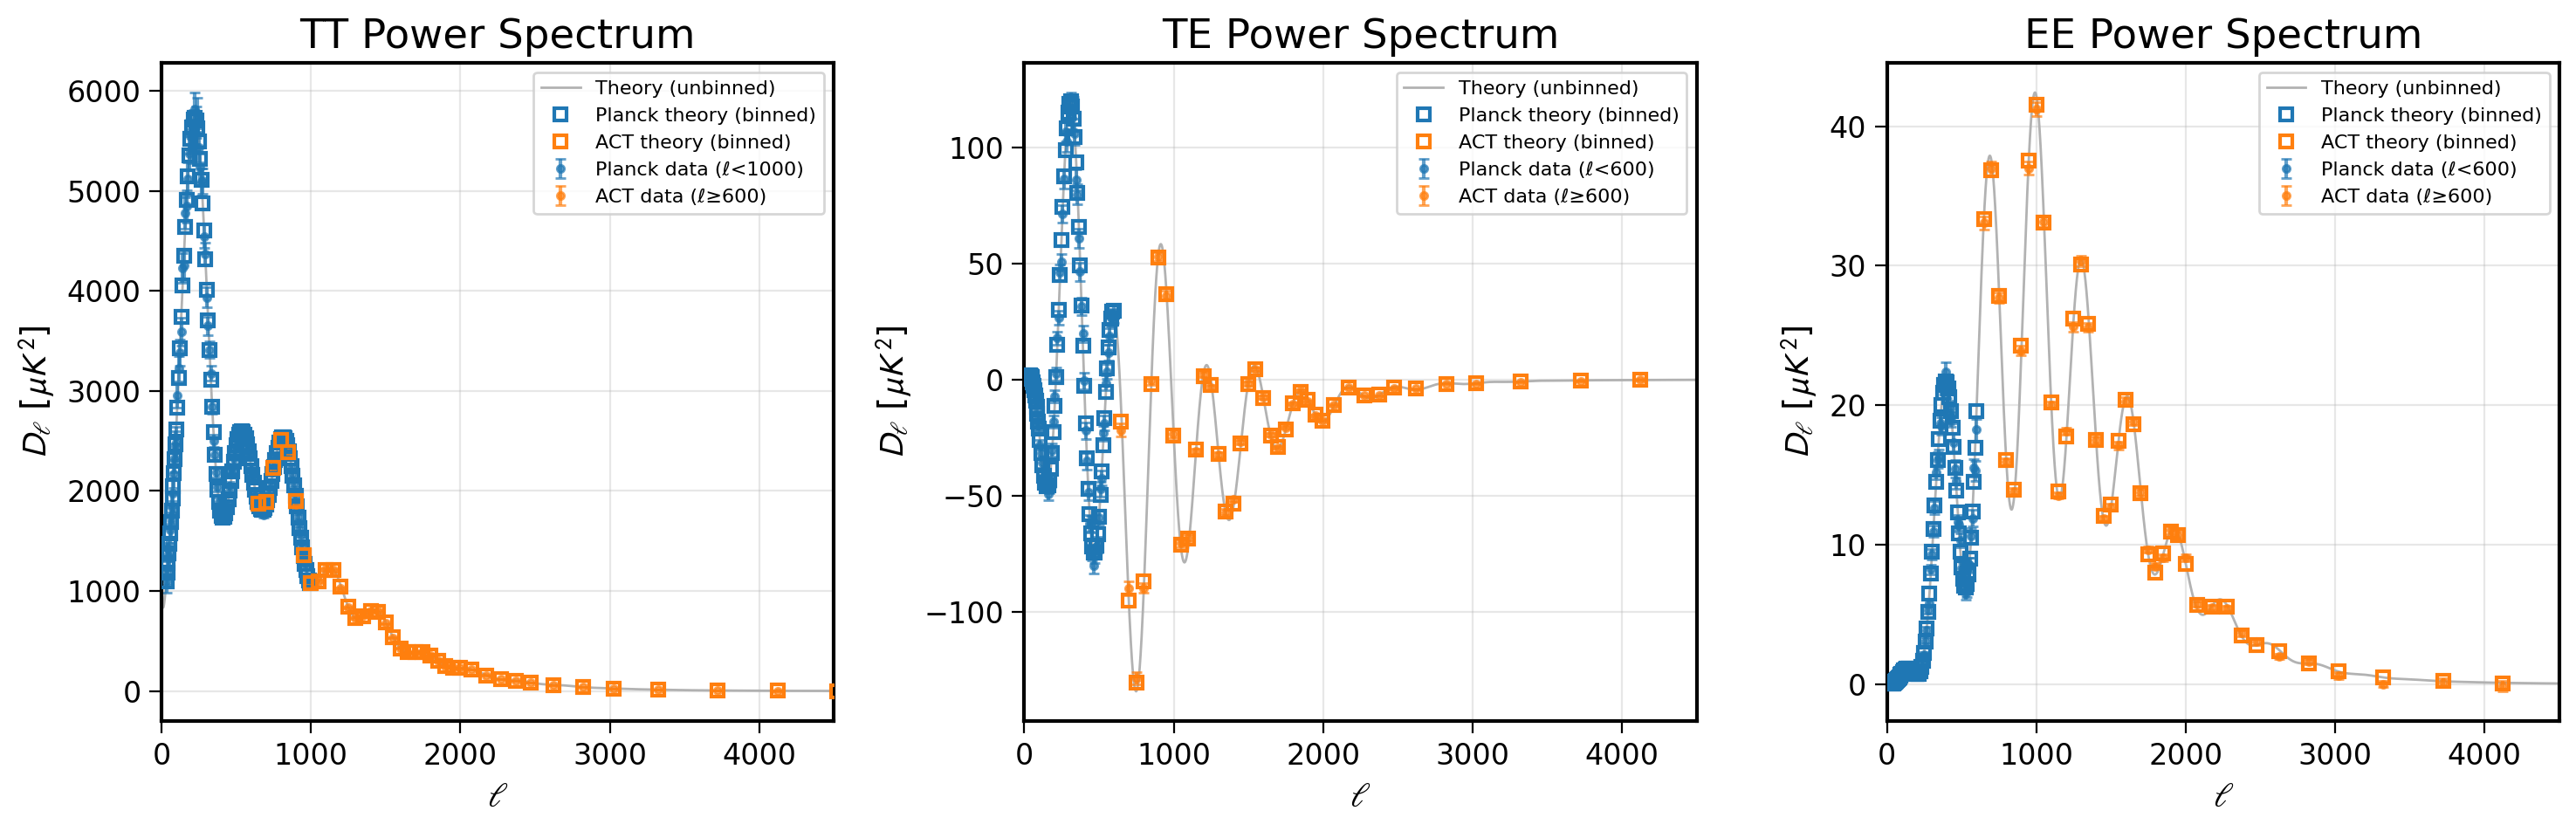

Saved: planck_act_binned_theory.png


In [9]:
# Plot data vs binned theory (with ell cuts applied)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    cuts = ELL_CUTS[name]
    
    # Plot unbinned theory curve (gray, for reference)
    th = theory_spectra[name]
    ax.plot(th['ells'], th['dls'], 'k-', lw=1, alpha=0.3, label='Theory (unbinned)', zorder=0)
    
    # Planck: data and binned theory (ℓ < planck_max)
    if name in planck_cut and name in planck_theory_binned:
        p_data = planck_cut[name]
        p_theory = planck_theory_binned[name]
        
        # Apply cut to binned theory
        mask = p_theory['ells'] < cuts['planck_max']
        
        ax.errorbar(p_data['ells'], p_data['dls'], yerr=p_data['errs'],
                   fmt='o', capsize=2, ms=3, color='C0', alpha=0.7,
                   label=f"Planck data (ℓ<{cuts['planck_max']})", zorder=2)
        ax.plot(p_theory['ells'][mask], p_theory['dls'][mask], 
               's', ms=5, color='C0', mfc='none', mew=1.5,
               label='Planck theory (binned)', zorder=3)
    
    # ACT: data and binned theory (ℓ >= act_min)
    if name in act_cut and name in act_theory_binned:
        a_data = act_cut[name]
        a_theory = act_theory_binned[name]
        
        # Apply cut to binned theory
        mask = a_theory['ells'] >= cuts['act_min']
        
        ax.errorbar(a_data['ells'], a_data['dls'], yerr=a_data['errs'],
                   fmt='o', capsize=2, ms=3, color='C1', alpha=0.7,
                   label=f"ACT data (ℓ≥{cuts['act_min']})", zorder=2)
        ax.plot(a_theory['ells'][mask], a_theory['dls'][mask],
               's', ms=5, color='C1', mfc='none', mew=1.5,
               label='ACT theory (binned)', zorder=3)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 4500)

plt.tight_layout()
plt.savefig('planck_act_binned_theory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_binned_theory.png")

## 6. Plot Combined Bandpowers

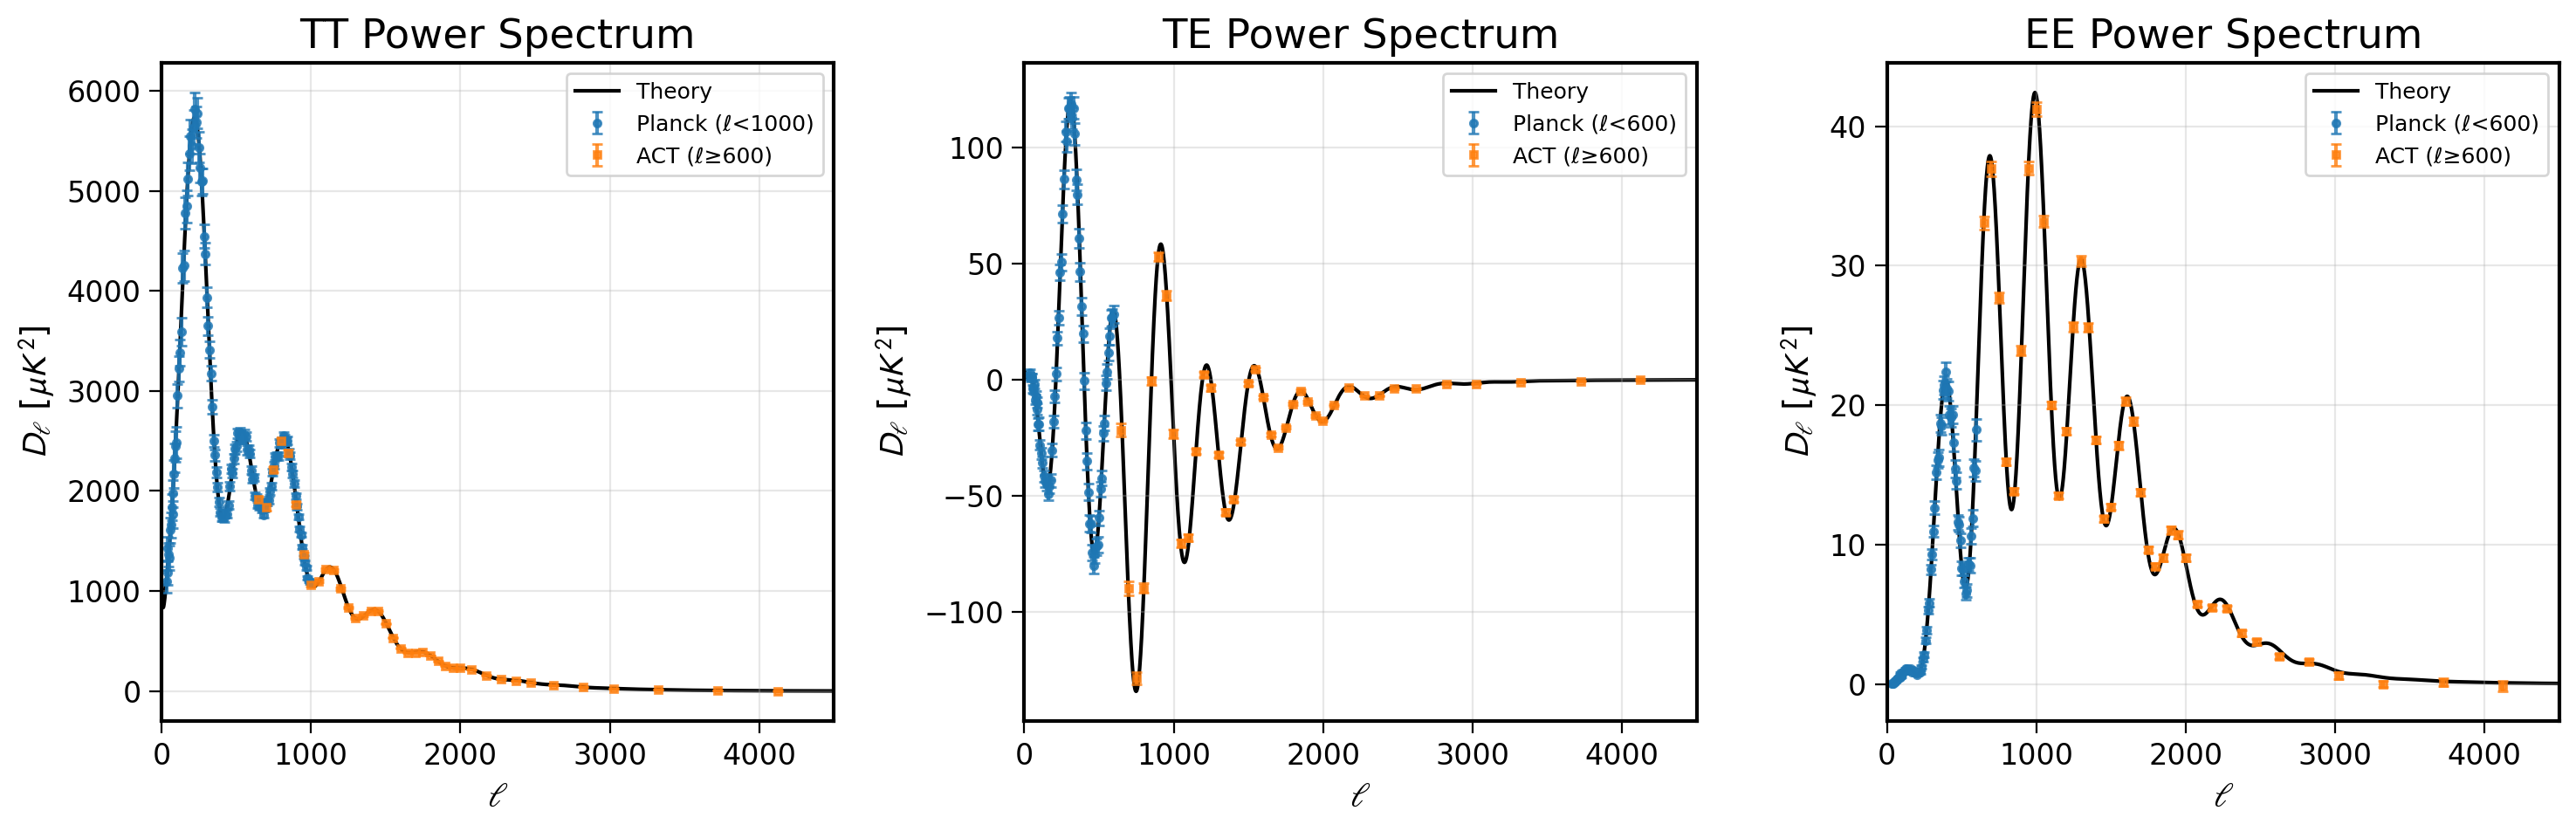

Saved: planck_act_combined_spectra.png


In [10]:
# Plot combined spectra with theory curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    # Plot theory curve (gray, behind data)
    if name in theory_spectra:
        th = theory_spectra[name]
        ax.plot(th['ells'], th['dls'], 'black', lw=1.5, alpha=1, label='Theory', zorder=1)
    
    # Plot Planck data (blue)
    if name in planck_cut:
        p = planck_cut[name]
        ax.errorbar(p['ells'], p['dls'], yerr=p['errs'], 
                   fmt='o', capsize=2, ms=3, color='C0', alpha=0.8,
                   label=f"Planck (ℓ<{ELL_CUTS[name]['planck_max']})", zorder=2)
    
    # Plot ACT data (orange)
    if name in act_cut:
        a = act_cut[name]
        ax.errorbar(a['ells'], a['dls'], yerr=a['errs'],
                   fmt='s', capsize=2, ms=3, color='C1', alpha=0.8,
                   label=f"ACT (ℓ≥{ELL_CUTS[name]['act_min']})", zorder=2)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set appropriate y-limits
    if name == 'TT':
        ax.set_xlim(0, 4500)
    elif name in ['TE', 'EE']:
        ax.set_xlim(0, 4500)

plt.tight_layout()
plt.savefig('planck_act_combined_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_combined_spectra.png")

## 7. Covariance Matrices with ell Cuts

Apply the same covariance cutting pattern as `PlanckActCut.py`:
- Zero out rows/columns for bins outside the ell range
- Set diagonal to 1e10 (effectively infinite variance)
- This allows the full covariance to be inverted while excluding cut bins

In [11]:
from scipy.io import FortranFile

# Load Planck covariance using Fortran binary format (same as cobaya PlanckPlikLite)
planck_cov_file = planck_dir + 'c_matrix_plik_v22.dat'
f = FortranFile(planck_cov_file, 'r')
planck_cov_cl = f.read_reals(dtype=float).reshape((613, 613))
planck_cov_cl = np.tril(planck_cov_cl) + np.tril(planck_cov_cl, -1).T  # make symmetric

print(f"Planck full covariance (Cl units): {planck_cov_cl.shape}")

# Load bin edges for Planck (same as PlanckActCut.py)
bin_lmin_offset = 30  # from plik_lite_v22.dataset
blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset

# Apply ell cuts to Planck covariance following PlanckActCut.py pattern
# Uses shared ELL_CUTS dict for consistency with bandpower cuts
cl_names = ['TT', 'TE', 'EE']
planck_nbins = [215, 199, 199]  # nbintt, nbinte, nbinee

planck_cov_cut = planck_cov_cl.copy()
ix = 0
uses = {}

for xy, nbin in zip(cl_names, planck_nbins):
    lmin = 0  # Planck starts at low ell
    lmax = ELL_CUTS[xy]['planck_max']  # Use shared ELL_CUTS
    
    idx = np.arange(nbin)  # bin indices for this spectrum
    
    # Mask: bins where blmin < lmin OR blmax > lmax (following PlanckActCut.py)
    mask = np.logical_or(blmin[idx] < lmin, blmax[idx] > lmax)
    to_cut = idx[mask] + ix  # offset by cumulative index
    
    # Apply cuts: zero out rows/columns, set diagonal to 1e10
    planck_cov_cut[to_cut, :] = 0.0
    planck_cov_cut[:, to_cut] = 0.0
    planck_cov_cut[to_cut, to_cut] = 1e10
    
    n_kept = nbin - mask.sum()
    if n_kept > 0:
        uses[xy] = n_kept
    
    print(f"Planck {xy}: cut {mask.sum()} bins (ℓ>{lmax}), kept {n_kept} bins")
    
    ix += nbin

# Compute inverse covariance
planck_invcov = np.linalg.inv(planck_cov_cut)
print(f"\nPlanck cut covariance: {planck_cov_cut.shape}, condition number: {np.linalg.cond(planck_cov_cut):.2e}")

# ACT covariance from SACC (already in Dl units)
act_cov_full = act_s.covariance.covmat.copy()
print(f"ACT full covariance (Dl units): {act_cov_full.shape}")

# Apply ell cuts to ACT covariance (cut bins BELOW act_min, keep high ell)
# Uses shared ELL_CUTS dict for consistency with bandpower cuts
act_nbins = [45, 40, 42]  # TT, TE, EE

act_cov_cut = act_cov_full.copy()
ix = 0

for xy, nbin in zip(cl_names, act_nbins):
    lmin = ELL_CUTS[xy]['act_min']  # Use shared ELL_CUTS
    
    # Get ell values for ACT bins from SACC
    sacc_type = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}[xy]
    indices = act_s.indices(sacc_type)
    ells = np.array([act_s.data[i].get_tag('ell') for i in indices])
    
    idx = np.arange(nbin)
    mask = ells < lmin  # cut bins below lmin
    to_cut = idx[mask] + ix
    
    act_cov_cut[to_cut, :] = 0.0
    act_cov_cut[:, to_cut] = 0.0
    act_cov_cut[to_cut, to_cut] = 1e10
    
    n_kept = nbin - mask.sum()
    print(f"ACT {xy}: cut {mask.sum()} bins (ℓ<{lmin}), kept {n_kept} bins")
    
    ix += nbin

act_invcov = np.linalg.inv(act_cov_cut)
print(f"\nACT cut covariance: {act_cov_cut.shape}, condition number: {np.linalg.cond(act_cov_cut):.2e}")

Planck full covariance (Cl units): (613, 613)
Planck TT: cut 101 bins (ℓ>1000), kept 114 bins
Planck TE: cut 130 bins (ℓ>600), kept 69 bins
Planck EE: cut 130 bins (ℓ>600), kept 69 bins

Planck cut covariance: (613, 613), condition number: 6.65e+26
ACT full covariance (Dl units): (127, 127)
ACT TT: cut 1 bins (ℓ<600), kept 44 bins
ACT TE: cut 1 bins (ℓ<600), kept 39 bins
ACT EE: cut 3 bins (ℓ<600), kept 39 bins

ACT cut covariance: (127, 127), condition number: 4.13e+11


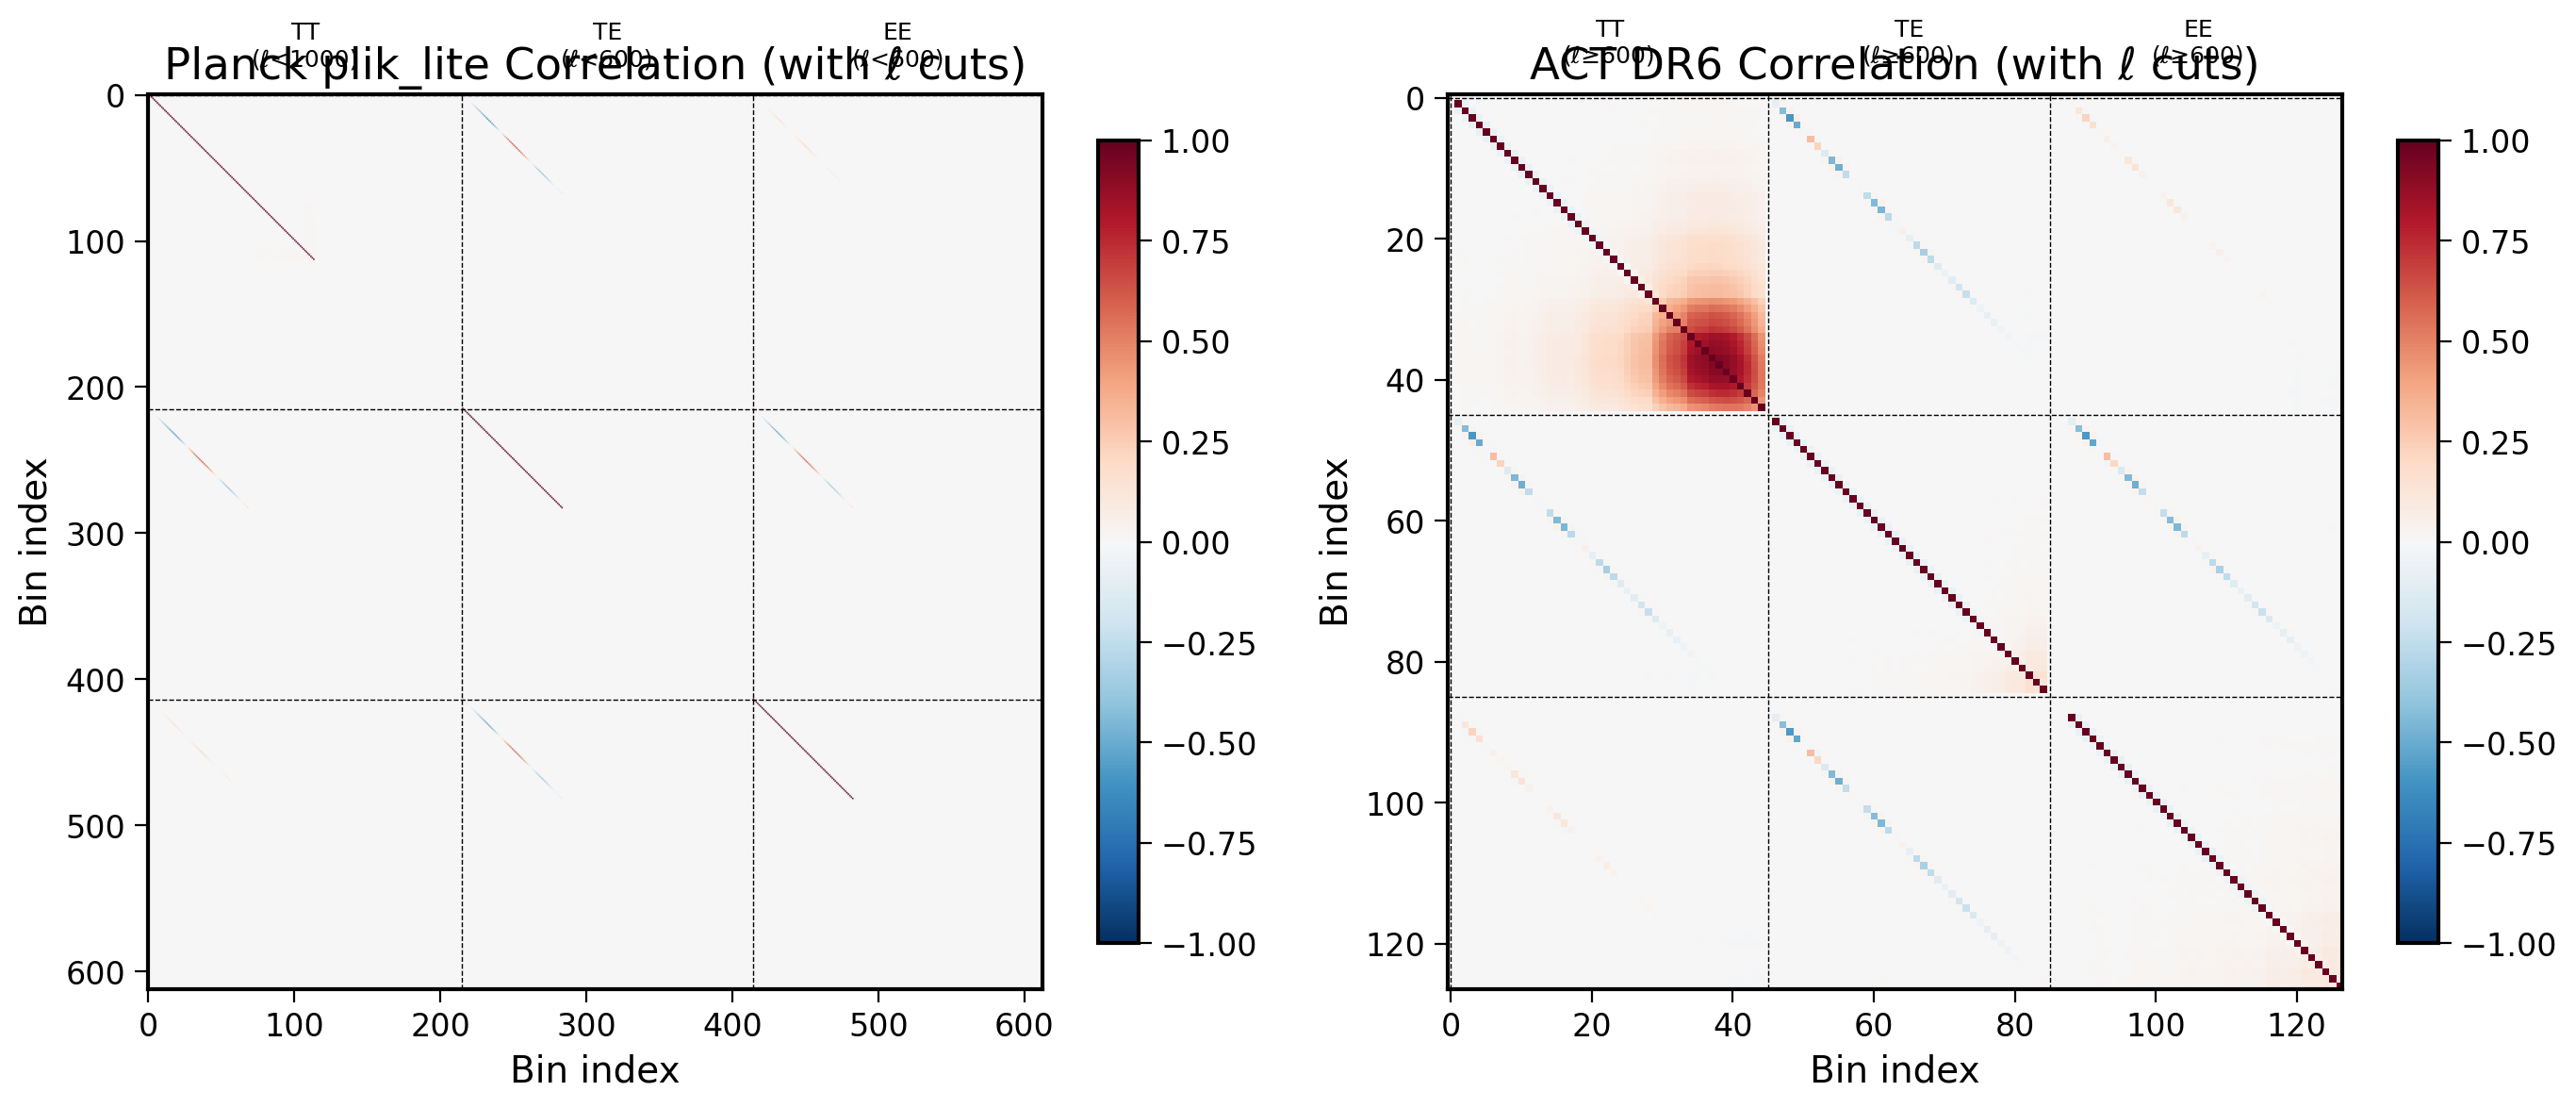

Saved: planck_act_correlations.png

Planck bins kept: {'TT': 114, 'TE': 69, 'EE': 69}
ACT bins with ℓ<600 cut: TT=1, TE=1, EE=3


In [12]:
# Plot covariance matrices side by side (after applying ell cuts)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Planck correlation matrix (with cuts applied)
# Mask out the 1e10 diagonal entries for visualization
planck_cov_viz = planck_cov_cut.copy()
cut_mask = np.diag(planck_cov_cut) > 1e9
planck_cov_viz[cut_mask, :] = np.nan
planck_cov_viz[:, cut_mask] = np.nan

planck_std = np.sqrt(np.abs(np.diag(planck_cov_cut)))
planck_std[planck_std > 1e4] = 1  # avoid division issues
planck_corr = planck_cov_cut / np.outer(planck_std, planck_std)
planck_corr[cut_mask, :] = 0
planck_corr[:, cut_mask] = 0

im1 = axes[0].imshow(planck_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
axes[0].set_title('Planck plik_lite Correlation (with ℓ cuts)')
axes[0].set_xlabel('Bin index')
axes[0].set_ylabel('Bin index')

# Add spectrum labels and cut regions
cumsum = [0, 215, 215+199, 215+199+199]
for i, (name, n, lmax) in enumerate(zip(['TT', 'TE', 'EE'], [215, 199, 199], [1000, 600, 600])):
    offset = cumsum[i]
    axes[0].axhline(offset, color='k', lw=0.5, ls='--')
    axes[0].axvline(offset, color='k', lw=0.5, ls='--')
    axes[0].text(offset + n/2, -20, f'{name}\n(ℓ<{lmax})', ha='center', fontsize=9)

plt.colorbar(im1, ax=axes[0], shrink=0.8)

# ACT correlation matrix (with cuts applied)
act_std = np.sqrt(np.abs(np.diag(act_cov_cut)))
act_std[act_std > 1e4] = 1
act_corr = act_cov_cut / np.outer(act_std, act_std)
act_cut_mask = np.diag(act_cov_cut) > 1e9
act_corr[act_cut_mask, :] = 0
act_corr[:, act_cut_mask] = 0

im2 = axes[1].imshow(act_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
axes[1].set_title('ACT DR6 Correlation (with ℓ cuts)')
axes[1].set_xlabel('Bin index')
axes[1].set_ylabel('Bin index')

# Add ACT spectrum labels (TT=45, TE=40, EE=42)
act_cumsum = [0, 45, 45+40, 45+40+42]
for i, (name, n) in enumerate(zip(['TT', 'TE', 'EE'], [45, 40, 42])):
    offset = act_cumsum[i]
    axes[1].axhline(offset, color='k', lw=0.5, ls='--')
    axes[1].axvline(offset, color='k', lw=0.5, ls='--')
    axes[1].text(offset + n/2, -5, f'{name}\n(ℓ≥600)', ha='center', fontsize=9)

plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('planck_act_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_correlations.png")
print(f"\nPlanck bins kept: {uses}")
print(f"ACT bins with ℓ<600 cut: TT={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_00'))}, " +
      f"TE={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_0e'))}, " +
      f"EE={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_ee'))}")

## 8. Summary

### Planck+ACT Combination Strategy

The PlanckActCut combination uses Planck at low ℓ and ACT at high ℓ:

| Spectrum | Planck Range | ACT Range | Overlap |
|----------|--------------|-----------|---------|
| **TT** | ℓ < 1000 | ℓ ≥ 600 | 600 ≤ ℓ < 1000 |
| **TE** | ℓ < 600 | ℓ ≥ 600 | None |
| **EE** | ℓ < 600 | ℓ ≥ 600 | None |

### Data Products Used

| Source | Data | Covariance |
|--------|------|------------|
| **Planck plik_lite** | `cl_cmb_plik_v22.dat` | `c_matrix_plik_v22.dat` (Fortran binary) |
| **ACT DR6 CMB-only** | SACC bandpowers | SACC covariance |

### Use in Lensing Likelihood

1. **Normalization (dAL/dC)**: Lensing normalization depends on CMB power spectra
2. **N1 Bias**: Connected 4-point contribution depends on TT, TE, EE
3. **CMB-marginalized covariance**: For `lens_only=True` mode

In [13]:
# Print summary statistics
print("=" * 60)
print("PLANCK + ACT COMBINATION SUMMARY")
print("=" * 60)

print("\n--- Original Data ---")
for name in ['TT', 'TE', 'EE']:
    if name in planck_spectra:
        p = planck_spectra[name]
        print(f"Planck {name}: {len(p['ells'])} bins, ℓ=[{p['ells'][0]:.0f}, {p['ells'][-1]:.0f}]")
    if name in act_spectra:
        a = act_spectra[name]
        print(f"ACT {name}: {len(a['ells'])} bins, ℓ=[{a['ells'][0]:.0f}, {a['ells'][-1]:.0f}]")

print("\n--- After ell Cuts ---")
total_planck = 0
total_act = 0
for name in ['TT', 'TE', 'EE']:
    cuts = ELL_CUTS[name]
    if name in planck_cut:
        p = planck_cut[name]
        print(f"Planck {name} (ℓ<{cuts['planck_max']}): {len(p['ells'])} bins, ℓ=[{p['ells'][0]:.0f}, {p['ells'][-1]:.0f}]")
        total_planck += len(p['ells'])
    if name in act_cut:
        a = act_cut[name]
        print(f"ACT {name} (ℓ≥{cuts['act_min']}): {len(a['ells'])} bins, ℓ=[{a['ells'][0]:.0f}, {a['ells'][-1]:.0f}]")
        total_act += len(a['ells'])

print(f"\n--- Combined Dataset ---")
print(f"Total Planck bins: {total_planck}")
print(f"Total ACT bins: {total_act}")
print(f"Combined total: {total_planck + total_act}")

print(f"\n--- Covariance ---")
print(f"Planck covariance: {planck_cov_cl.shape}")
print(f"ACT covariance: {act_cov_full.shape}")
print("Note: Covariances are treated as block-diagonal (independent)")

PLANCK + ACT COMBINATION SUMMARY

--- Original Data ---
Planck TT: 215 bins, ℓ=[32, 2492]
ACT TT: 45 bins, ℓ=[598, 6124]
Planck TE: 199 bins, ℓ=[32, 1988]
ACT TE: 40 bins, ℓ=[598, 4124]
Planck EE: 199 bins, ℓ=[32, 1988]
ACT EE: 42 bins, ℓ=[498, 4124]

--- After ell Cuts ---
Planck TT (ℓ<1000): 114 bins, ℓ=[32, 995]
ACT TT (ℓ≥600): 44 bins, ℓ=[648, 6124]
Planck TE (ℓ<600): 70 bins, ℓ=[32, 599]
ACT TE (ℓ≥600): 39 bins, ℓ=[648, 4124]
Planck EE (ℓ<600): 70 bins, ℓ=[32, 599]
ACT EE (ℓ≥600): 39 bins, ℓ=[648, 4124]

--- Combined Dataset ---
Total Planck bins: 254
Total ACT bins: 122
Combined total: 376

--- Covariance ---
Planck covariance: (613, 613)
ACT covariance: (127, 127)
Note: Covariances are treated as block-diagonal (independent)
